In [10]:
import numpy as np
from scipy.optimize import minimize
import pandas as pd
import GPy
from scipy.special import expit
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.spatial import distance
import statsmodels.api as sm
import warnings
import numpy as np
from scipy.optimize import differential_evolution
from scipy.stats import rankdata
from sklearn.cross_decomposition import CCA
import math
import copy
from math import log
from collections import Counter
import pickle
from sklearn.linear_model import Lasso
from itertools import product
import random
warnings.filterwarnings("ignore")

In [5]:
# Read beta back from the file
beta_star = np.load('beta_star.npy')
print("beta_star:", beta_star)
n_features = len(beta_star)

np.sum(beta_star[beta_star > 0])

beta_star: [ 0.         -6.43402506  0.          0.          0.          0.
 -3.46300275  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          9.71065693
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          3.39035674  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -3.66072697  0.          0.
  0.          0.          0.          0.          6.79417452  0.
  0.         -3.0605458   0.          0.          0.          0.
  0.  

21.344585014099877

In [6]:
from sklearn.linear_model import Lasso

def preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star):
    """
    Implements the preconditioning LASSO bandit algorithm.

    Args:
        phi (float): Regularization parameter for optimization.
        T (int): Total time steps.
        C_max_wave (float): F_t matrix eigenvalue constraint.
        L (float): Upper limit for X values.
        error_std (float): Standard deviation for error term.
        Y_t (array): Initial response vector.
        X_t (array): Initial feature matrix.
        beta_star (array): True coefficient vector for simulation.

    Returns:
        Y_t, X_t: Updated response vector and feature matrix.
    """
    n_features = X_t.shape[1]  # Number of features

    Y_t_exp = Y_t

    l_2_error_parameter = np.array([])

    for tau in range(len(Y_t), T):
        # Compute lambda for LASSO
        lamada = 2 * error_std * C_max_wave * L * np.sqrt(2 * (2 * np.log(tau) + np.log(n_features)) / tau)

        U_t, D_t, V_t_T = np.linalg.svd(X_t, full_matrices=False)
        # Compute F_t using the formula F_t = sqrt(t) * U_t @ D_t_inv @ U_t.T
        F_t = np.sqrt(tau) * U_t @ np.linalg.pinv(np.diag(D_t)) @ U_t.T
        # Compute transformed variables
        Y_t_tran = F_t @ Y_t
        X_t_tran = F_t @ X_t
        

        # Perform LASSO regression with lambda using Y_t_tran and X_t_tran
        lasso = Lasso(alpha=lamada, fit_intercept=False)
        lasso.fit(X_t_tran, Y_t_tran)  # Fit the model to get beta estimates
        beta_esti = lasso.coef_  # Estimated beta values
        print(f"parameter square error:{np.sqrt(sum((beta_esti - beta_star)**2))}")
        s_esti = np.count_nonzero(beta_esti)  # Number of non-zero coefficients

        # Perform optimization to find X_max
        # Check if expected Y_t has not changed for 20 iterations
        if len(Y_t_exp) >= 20 and np.all(Y_t_exp[-20:] == Y_t_exp[-1]):
            # Keep X_max unchanged
            X_max = X_t[-1]

        else:
            # Perform optimization to find X_max
            X_max = optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau)


        # Generate Y_max based on true beta_star
        Y_max_exp = beta_star @ X_max

        
        Y_max = beta_star @ X_max + np.random.normal(0, error_std, 1)
        
        #print(f"time {tau}: beta {beta_esti}")
        print(f"time {tau}: reward {Y_max}")
        print(f"time {tau}: mean reward {beta_star @ X_max}")
        #print(f"time {tau}: action {X_max}")

        l_2_error_parameter = np.append(l_2_error_parameter, np.sqrt(sum((beta_esti - beta_star)**2)))

        # Append X_max and Y_max to X_t and Y_t
        Y_t = np.append(Y_t, Y_max)
        X_t = np.vstack([X_t, X_max])

        Y_t_exp = np.append(Y_t_exp, Y_max_exp)

    return Y_t, X_t, Y_t_exp, l_2_error_parameter


In [32]:
def optimization(beta_esti, s_esti, X_t, L, lamada, phi, tau):
    """
    Perform optimization where each variable in X_max can only take values 0 or L.

    Args:
        beta_esti (numpy array): Estimated coefficients (beta).
        s_esti (float): Estimated parameter for scaling.
        X_t (numpy array): Existing feature matrix.
        L (float): Maximum value that variables in X_max can take.
        lamada (float): Regularization parameter.
        phi (float): Parameter for constraint.
        tau (float): Scaling parameter for matrix inversion.

    Returns:
        numpy array: Optimized X_max vector.
    """

    epochs = 2
    
    # Define the objective function
    def objective(X_max):
        X_max = np.array(X_max)
        sqrt_term = np.sqrt(
            X_max @ np.linalg.pinv((1 / tau) * (X_t.T @ X_t)) @ X_max.reshape(-1, 1)
            * (np.sqrt(np.linalg.eigvalsh((1 / tau) * (X_t.T @ X_t)).max()))
        )
        constant = (4 * np.sqrt(s_esti) * lamada / phi)
        return -(beta_esti @ X_max + constant * sqrt_term)  # Negate for maximization

    # Initialize X_max with all zeros
    num_vars = len(beta_esti)
    X_max = np.random.choice([0, L], size=num_vars)

    for epoch in range(epochs):
        current_value = objective(X_max)

        # Greedy optimization within this epoch
        for i in range(num_vars):
            # Flip the value of X_max[i] (0 -> L, L -> 0)
            original_value = X_max[i]
            X_max[i] = 0 if original_value == L else L
            new_value = objective(X_max)

            # If the objective improves, keep the change; otherwise, revert
            if new_value < current_value:
                current_value = new_value
            else:
                X_max[i] = original_value

    print(f"Final Objective Value: {current_value}")
    return X_max

In [33]:
def while_preconditioning_lasso_bandit(beta_star):
    error_std = 1
    phi = 50
    C_max_wave = 1
    t = 2
    T = 1000 + t
    
    L = 1
    # Generate X where the first column is 1, and the remaining columns are random values
    X_t = np.ones((t, n_features))  # Start with an array of ones
    X_t[:, 1:] = np.random.uniform(0, L, (t, n_features - 1))  # Fill the remaining columns with random values
    
    # Generate random error term
    error_t = np.random.normal(0, error_std, t)
    
    # Compute Y = X @ beta_star + error_t
    Y_t = X_t @ beta_star + error_t
    
    Y_T, X_T, Y_t_exp, l_2_error_parameter = preconditioning_lasso_bandit(phi, T, C_max_wave, L, error_std, Y_t, X_t, beta_star)

    return Y_t_exp, l_2_error_parameter
    

In [34]:
cumulative_regre_times = []
l_2_error_parameter_times = []

# Run the experiment 10 times
for times in range(10):
    # Ensure beta_star and `t` are properly initialized
    Y_t_exp, l_2_error_parameter = while_preconditioning_lasso_bandit(beta_star)  # Replace with the actual function
    
    Y_t_to_T = Y_t_exp
    
    # Calculate instantaneous regret
    instantaneous_regret = np.sum(beta_star[beta_star > 0]) - Y_t_to_T
    instantaneous_regret = np.where(instantaneous_regret < 0.002, 0, instantaneous_regret)  # Threshold adjustment

    # Calculate cumulative regret
    cumulative_regret = np.cumsum(instantaneous_regret)

    # Append results to the list
    cumulative_regre_times.append(cumulative_regret)
    l_2_error_parameter_times.append(l_2_error_parameter)

# The results `cumulative_regre_times` and `l_2_error_parameter_times` now store the outcomes of all experiments.


parameter square error:17.234084058325656
Final Objective Value: [-0.]
time 2: reward [3.86378685]
time 2: mean reward 2.1449076684005313
parameter square error:17.234084058325656
Final Objective Value: [-0.]
time 3: reward [-1.34788883]
time 3: mean reward -1.9952440781458316
parameter square error:17.234084058325656
Final Objective Value: [-0.]
time 4: reward [-4.69278554]
time 4: mean reward -3.300577504047885
parameter square error:17.234084058325656
Final Objective Value: [nan]
time 5: reward [1.56457562]
time 5: mean reward 2.307688235666637
parameter square error:17.234084058325656
Final Objective Value: [nan]
time 6: reward [-9.74169588]
time 6: mean reward -7.871292586550283
parameter square error:17.234084058325656
Final Objective Value: [-0.]
time 7: reward [-10.65933278]
time 7: mean reward -10.094752028571676
parameter square error:17.234084058325656
Final Objective Value: [nan]
time 8: reward [-4.42657342]
time 8: mean reward -3.9568434278840847
parameter square error:17.

In [35]:
# Convert lists to NumPy arrays for easier computation
cumulative_regret_times = np.array(cumulative_regre_times)
l_2_error_parameter_times = np.array(l_2_error_parameter_times)

# Calculate the mean and standard deviation along the "times" axis
cumulative_regret_mean = np.mean(cumulative_regret_times, axis=0)
cumulative_regret_std = np.std(cumulative_regret_times, axis=0)

l_2_error_parameter_mean = np.mean(l_2_error_parameter_times, axis=0)
l_2_error_parameter_std = np.std(l_2_error_parameter_times, axis=0)

# Print or use the results as needed
print("Cumulative Regret Mean:", cumulative_regret_mean)
print("Cumulative Regret Std:", cumulative_regret_std)
print("L2 Error Parameter Mean:", l_2_error_parameter_mean)
print("L2 Error Parameter Std:", l_2_error_parameter_std)

Cumulative Regret Mean: [  23.33162471   46.35540393   73.43235022 ... 4725.5398206  4725.5398206
 4725.5398206 ]
Cumulative Regret Std: [  5.94716473   6.67741405   9.85652948 ... 148.31268516 148.31268516
 148.31268516]
L2 Error Parameter Mean: [1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72340841e+01 1.72340841e+01
 1.72340841e+01 1.72340841e+01 1.72185794e+01 1.72340841e+01
 1.72012268e+01 1.70982924e+01 1.69365909e+01 1.68697118e+01
 1.66569373e+01 1.63450030e+01 1.61727708e+01 1.61676566e+01
 1.68308810e+01 1.82928288e+01 2.14175280e+01 2.72861102e+01
 3.81169227e+01 5.57173266e+01 8.13807120e+01 1.25960395e+02
 1.94351525e+02 3.26848394e+02 5.51924323e+02 8.93292589e+02
 1.52950208e+03 2.460

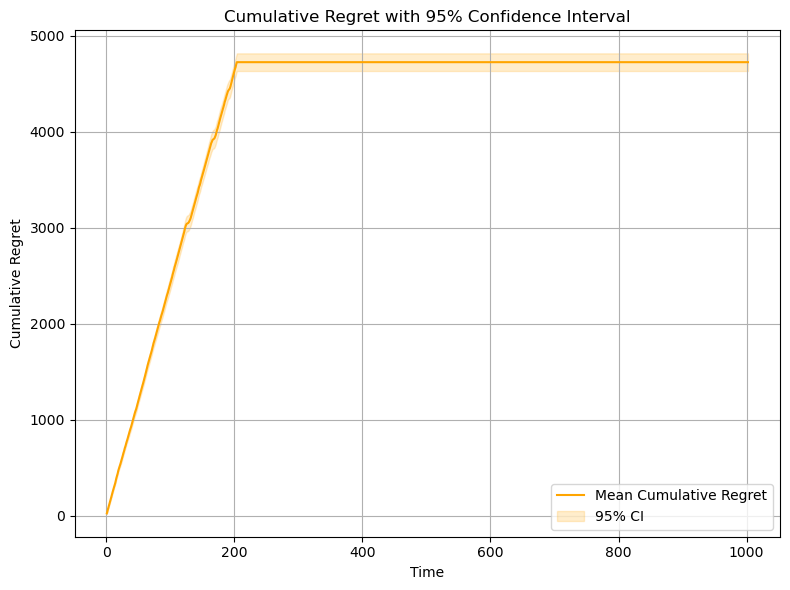

In [36]:
# Calculate the 95% confidence interval for the cumulative regret
lower_bound = cumulative_regret_mean - 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))
upper_bound = cumulative_regret_mean + 1.96 * (cumulative_regret_std / np.sqrt(cumulative_regret_times.shape[0]))

# Plot the mean cumulative regret with confidence intervals
plt.figure(figsize=(8, 6))
time_steps = range(1, len(cumulative_regret_mean) + 1)

# Plot the mean line
plt.plot(time_steps, cumulative_regret_mean, label='Mean Cumulative Regret', color='orange')

# Fill the 95% confidence interval
plt.fill_between(time_steps, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% CI')

# Add title, labels, and legend
plt.title('Cumulative Regret with 95% Confidence Interval')
plt.xlabel('Time')
plt.ylabel('Cumulative Regret')
plt.grid()
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()


In [37]:
np.save('cumulative_regret_pre-lasso-stochastic-bandit-d200-s10_10times.npy', cumulative_regret_times)
np.save('l_2_error_parameter_pre-lasso-stochastic-bandit-d200-s10_10times.npy', l_2_error_parameter_times)